# Global Inflation Analysis Notebook

- Data source: World Bank WDI (`FP.CPI.TOTL.ZG`)
- Download date: 2026-04-08
- Objective: exploratory inflation analysis with practical user value

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Configure plotting defaults for clean notebook rendering.
plt.rcParams["axes.unicode_minus"] = False

DATA_FILE = "data/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv"
META_FILE = "data/Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv"

In [8]:
raw = pd.read_csv(DATA_FILE, skiprows=4)
raw = raw.drop(columns=[c for c in raw.columns if c.startswith("Unnamed")], errors="ignore")
year_cols = [c for c in raw.columns if c.isdigit()]

df = raw.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Inflation",
)
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Inflation"] = pd.to_numeric(df["Inflation"], errors="coerce")

meta = pd.read_csv(META_FILE)
meta = meta[["Country Code", "Region", "IncomeGroup", "TableName"]]
df = df.merge(meta, on="Country Code", how="left")
df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation,Region,IncomeGroup,TableName
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN,Latin America & Caribbean,High income,Aruba
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN,NaN,NaN,Africa Eastern and Southern
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN,Middle East & North Africa,Low income,Afghanistan
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN,NaN,NaN,Africa Western and Central
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN,Sub-Saharan Africa,Lower middle income,Angola


In [9]:
summary = df[["Inflation"]].describe()
missing_rate = df["Inflation"].isna().mean()
print(summary)
print(f"Missing rate: {missing_rate:.2%}")

          Inflation
count   9066.000000
mean      22.643882
std      317.642980
min      -17.640424
25%        2.135129
50%        4.831985
75%       10.085932
max    23773.131774
Missing rate: 48.36%


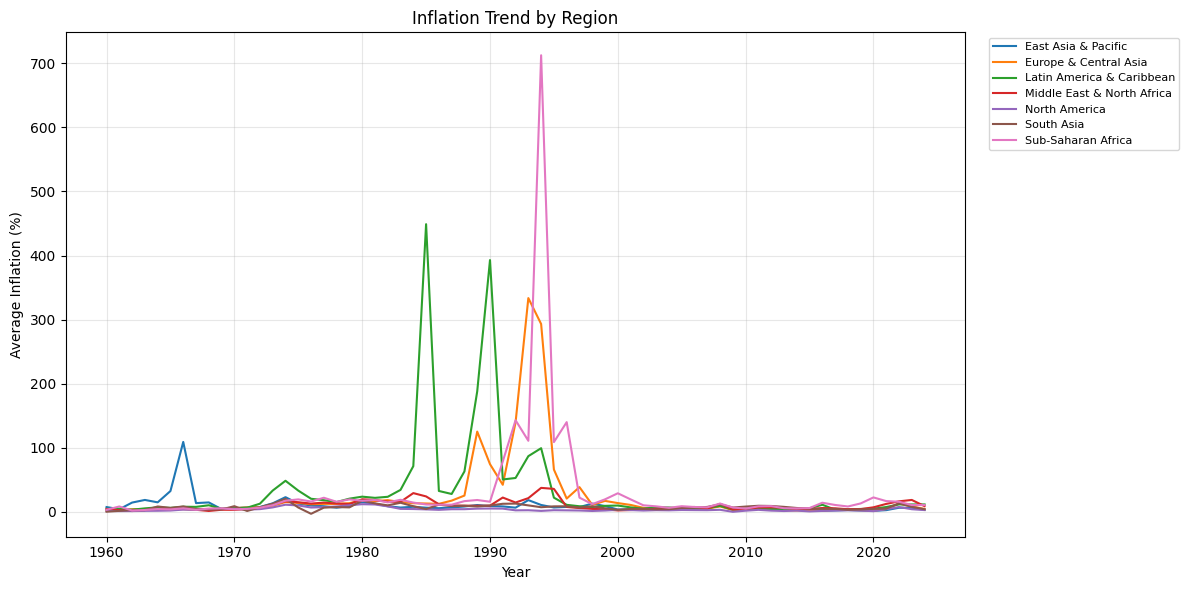

In [10]:
trend_df = (
    df.dropna(subset=["Inflation", "Region"])
      .groupby(["Year", "Region"], as_index=False)["Inflation"].mean()
)

plt.figure(figsize=(12, 6))
for region, sub_df in trend_df.groupby("Region"):
    plt.plot(sub_df["Year"], sub_df["Inflation"], label=region)

plt.title("Inflation Trend by Region")
plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

Year used for ranking: 2024, valid samples: 173


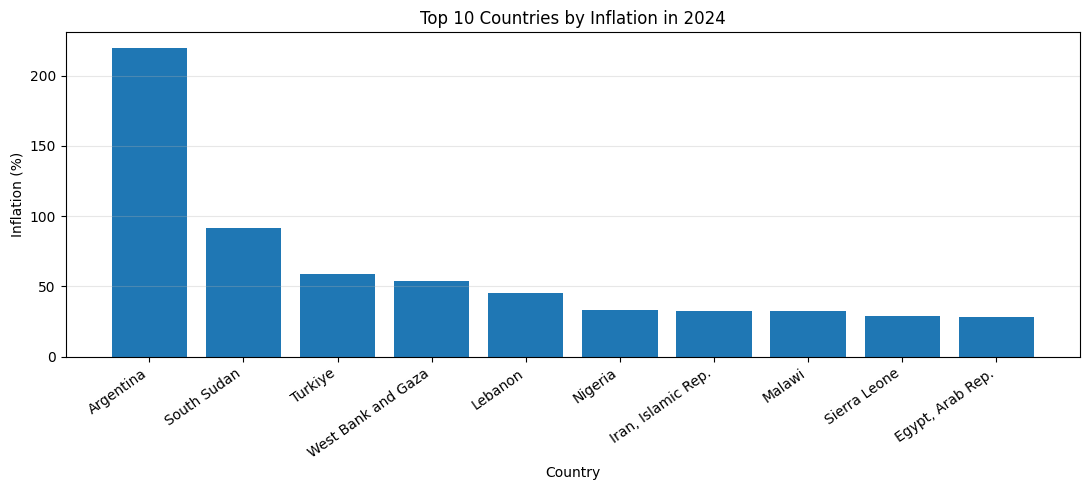

,Country Name,Inflation,Region
17033,Argentina,219.883929,Latin America & Caribbean
17240,South Sudan,91.440822,Sub-Saharan Africa
17268,Turkiye,58.506451,Europe & Central Asia
17220,West Bank and Gaza,53.669146,Middle East & North Africa
17154,Lebanon,45.243042,Middle East & North Africa
17198,Nigeria,33.242097,Sub-Saharan Africa
17136,"Iran, Islamic Rep.",32.455871,Middle East & North Africa
17192,Malawi,32.179650,Sub-Saharan Africa
17234,Sierra Leone,28.633750,Sub-Saharan Africa
17091,"Egypt, Arab Rep.",28.270590,Middle East & North Africa


In [11]:
# Use the latest year that still has valid inflation values.
year_stats = (
    df.groupby("Year", as_index=False)["Inflation"]
      .apply(lambda s: s.notna().sum())
      .rename(columns={"Inflation": "non_null_count"})
)
latest_year = int(year_stats[year_stats["non_null_count"] > 0]["Year"].max())
latest = df[(df["Year"] == latest_year) & (df["Inflation"].notna())]

# Optional: remove regional aggregate rows (rows with Region but no IncomeGroup).
latest = latest[latest["IncomeGroup"].notna()]

top10 = latest.nlargest(10, "Inflation")[["Country Name", "Inflation", "Region"]]
print(f"Year used for ranking: {latest_year}, valid samples: {len(latest)}")

plt.figure(figsize=(11, 5))
plt.bar(top10["Country Name"], top10["Inflation"])
plt.title(f"Top 10 Countries by Inflation in {latest_year}")
plt.xlabel("Country")
plt.ylabel("Inflation (%)")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

top10

## Key Findings

1. Inflation trajectories differ significantly across regions, especially during crisis periods.
2. In the latest usable year, high inflation is concentrated in a limited set of countries.
3. Data completeness varies by country, so missingness should be considered when interpreting results.